In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms #helps in converting images to numbers
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

Using Device cpu
Epoch1/5|Loss:329.7542
Epoch2/5|Loss:137.4864
Epoch3/5|Loss:92.8916
Epoch4/5|Loss:70.0005
Epoch5/5|Loss:54.8071
Total Accuracy: 97.58%
Model saved as mnist_model.pth 


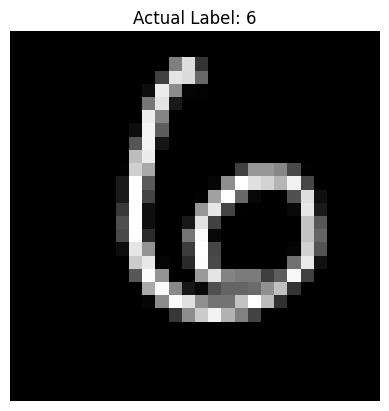

User picked image index 100
Actual Label:  6
Model Prediction:  6


In [12]:
# Select device: use GPU if available, else CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using Device", device)

transform = transforms.ToTensor() #convert images to tensors
train_data = MNIST(
    root = "data", #Folder to store/load the dataset
    train = True, #Train all images
    download = True, #Download if not already present
    transform = transform # Apply transform to images
)
test_data = MNIST(
    root = "data",
    train = False,
    download = True,
    transform = transform
)
train_loader = DataLoader( #Load training dataset
    train_data,
    batch_size = 64, #Number of samples per batch
    shuffle = True # Shuffle data every epoch
)
test_loader = DataLoader( #Load test dataset
    test_data,
    batch_size = 64,
    shuffle = False
)

# Define a simple fully connected neural network for MNIST
class DigitModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(28*28, 128), #Input layer: 28*28 pixels -> 128 neurons
        nn.ReLU(), #Activation
        nn.Linear(128, 64), #Hidden layer: 128 -> 64 neurons
        nn.ReLU(),
        nn.Linear(64,10) #Output layer: 64 -> 10 classes (digits 0-9)
    )

  def forward(self, x):
    return self.net(x) #Forward pass

# Initialize model and move to device (CPU/GPU)
model = DigitModel().to(device)

#Loss function for classification
loss_fn = nn.CrossEntropyLoss()

#Optimizer: Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
  model.train() #Set model to training mode
  total_loss = 0
  for images, labels in train_loader:
     images = images.view(images.size(0), -1).to(device) #Flatten images and move to device
     labels = labels.to(device) #Move labels to device
     optimizer.zero_grad() #Reset gradients
     outputs = model(images) #Forward pass
     loss = loss_fn(outputs, labels) #Compute loss
     loss.backward() #Backpropagation
     optimizer.step() #Update weights
     total_loss+=loss.item() #Accumulate loss
  print(f"Epoch{epoch+1}/{epochs}|Loss:{total_loss:.4f}")
# Evaluation
model.eval() #Set model to evaluation mode
correct = 0
total = 0
with torch.no_grad(): #Disable gradient calculation
  for images, labels in test_loader:
    images = images.view(images.size(0),-1).to(device) #Flatten and move to device
    labels = labels.to(device)
    outputs = model(images) #Forward pass
    predictions = outputs.argmax(dim=1) #Get predicted class
    correct+=(predictions==labels).sum().item() #Count correct predictions
    total+=labels.size(0) #Count total samples

# Calculate accuracy
accuracy = 100*correct/total
print(f"Total Accuracy: {accuracy:.2f}%")

#Save trained model
torch.save(model.state_dict(), "mnist_model.pth")
print("Model saved as mnist_model.pth ")

#Visualize a test image
index = 100
image, true_label = test_data[index]
plt.imshow(image.squeeze(), cmap = "gray")
plt.title(f"Actual Label: {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(1,-1).to(device)
with torch.no_grad():
  output = model(image_flat)
  predicted_label = output.argmax(dim=1).item() #Get predicted class

print("User picked image index", index)
print("Actual Label: ", true_label)
print("Model Prediction: ",predicted_label)